
# GVH Diagonal Cubic 0.2.18 — Quadratic Action and Ghost Spectrum
## Action quadratique, spectre linéaire, ghosts, tachyons et causalité

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.17 a établi, pour le modèle canonique minimal :

\[
N_{\rm DOF}=2+5=7.
\]

Cette version étudie la qualité physique des sept modes autour du vide de Minkowski :

\[
g_{\mu\nu}
=
\eta_{\mu\nu}
+
h_{\mu\nu},
\]

\[
\bar D_{\mu\nu}
=
0
+
\delta \bar D_{\mu\nu}.
\]

Les questions sont :

1. les coefficients cinétiques sont-ils positifs ?
2. les gradients ont-ils le bon signe ?
3. les masses effectives sont-elles réelles ?
4. les vitesses de propagation sont-elles causales ?
5. un mélange métrique–directionnel crée-t-il un ghost ?
6. le vide isotrope est-il stable ?

---

## Modèle minimal étudié

Le secteur directionnel quadratique est :

\[
S_D^{(2)}
=
\frac12
\int d^4x
\left[
K_D\dot q_A\dot q_A
-
G_D\partial_iq_A\partial_iq_A
-
m_D^2q_Aq_A
\right],
\]

avec :

\[
A=1,\dots,5.
\]

Le secteur gravitationnel physique contient les deux polarisations :

\[
h_+,
\qquad
h_\times.
\]

Le notebook étudie d'abord le cas découplé, puis des mélanges cinétiques et massiques exploratoires.

---

## Limite scientifique

Une preuve définitive d'absence de ghost pour un tenseur covariant complet exige l'action covariante complète avant fixation de jauge.

Les résultats ici sont définitifs pour l'action quadratique minimale explicitement écrite, mais exploratoires pour toute généralisation.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Variables physiques linéaires

Nous utilisons sept amplitudes :

\[
\Psi
=
(h_+,h_\times,q_1,q_2,q_3,q_4,q_5)^\mathsf T.
\]

L'action quadratique générale dans l'espace de Fourier est :

\[
S^{(2)}
=
\frac12
\int dt\,d^3k
\left[
\dot\Psi^\mathsf T
\mathbf K
\dot\Psi
-
\Psi^\mathsf T
\left(
k^2\mathbf G+\mathbf M^2
\right)
\Psi
\right].
\]


In [2]:

mode_names = [
    "h_plus",
    "h_cross",
    "q1",
    "q2",
    "q3",
    "q4",
    "q5"
]

n_modes = len(mode_names)
print("Nombre de modes :",n_modes)


Nombre de modes : 7



# 2. Matrices du modèle minimal découplé

Pour la gravité linéarisée correctement normalisée :

\[
K_h>0,
\qquad
G_h=K_h,
\qquad
m_h^2=0.
\]

Pour le secteur directionnel :

\[
K_D>0,
\qquad
G_D\ge0,
\qquad
m_D^2\ge0.
\]

Les matrices sont diagonales :

\[
\mathbf K
=
\operatorname{diag}
(K_h,K_h,K_D,\dots,K_D),
\]

\[
\mathbf G
=
\operatorname{diag}
(K_h,K_h,G_D,\dots,G_D),
\]

\[
\mathbf M^2
=
\operatorname{diag}
(0,0,m_D^2,\dots,m_D^2).
\]


In [3]:

K_h, K_D, G_D, m_D2 = sp.symbols(
    "K_h K_D G_D m_D2",
    real=True
)

K_matrix = sp.diag(
    K_h,
    K_h,
    K_D,
    K_D,
    K_D,
    K_D,
    K_D
)

G_matrix = sp.diag(
    K_h,
    K_h,
    G_D,
    G_D,
    G_D,
    G_D,
    G_D
)

M2_matrix = sp.diag(
    0,
    0,
    m_D2,
    m_D2,
    m_D2,
    m_D2,
    m_D2
)

display(K_matrix)
display(G_matrix)
display(M2_matrix)


⎡Kₕ  0    0    0    0    0    0 ⎤
⎢                               ⎥
⎢0   Kₕ   0    0    0    0    0 ⎥
⎢                               ⎥
⎢0   0   K_D   0    0    0    0 ⎥
⎢                               ⎥
⎢0   0    0   K_D   0    0    0 ⎥
⎢                               ⎥
⎢0   0    0    0   K_D   0    0 ⎥
⎢                               ⎥
⎢0   0    0    0    0   K_D   0 ⎥
⎢                               ⎥
⎣0   0    0    0    0    0   K_D⎦

⎡Kₕ  0    0    0    0    0    0 ⎤
⎢                               ⎥
⎢0   Kₕ   0    0    0    0    0 ⎥
⎢                               ⎥
⎢0   0   G_D   0    0    0    0 ⎥
⎢                               ⎥
⎢0   0    0   G_D   0    0    0 ⎥
⎢                               ⎥
⎢0   0    0    0   G_D   0    0 ⎥
⎢                               ⎥
⎢0   0    0    0    0   G_D   0 ⎥
⎢                               ⎥
⎣0   0    0    0    0    0   G_D⎦

⎡0  0   0     0     0     0     0  ⎤
⎢                                  ⎥
⎢0  0   0     0     0     0     0  ⎥
⎢                                  ⎥
⎢0  0  m_D2   0     0     0     0  ⎥
⎢                                  ⎥
⎢0  0   0    m_D2   0     0     0  ⎥
⎢                                  ⎥
⎢0  0   0     0    m_D2   0     0  ⎥
⎢                                  ⎥
⎢0  0   0     0     0    m_D2   0  ⎥
⎢                                  ⎥
⎣0  0   0     0     0     0    m_D2⎦


# 3. Valeurs propres cinétiques

Un ghost existe si une valeur propre physique de \(\mathbf K\) est négative.

Le spectre cinétique minimal est :

\[
\operatorname{spec}(\mathbf K)
=
\{K_h,K_h,K_D,K_D,K_D,K_D,K_D\}.
\]

Condition d'absence de ghost :

\[
K_h>0,
\qquad
K_D>0.
\]


In [4]:

kinetic_eigenvalues = list(K_matrix.diagonal())

kinetic_spectrum = pd.DataFrame({
    "mode":mode_names,
    "kinetic_eigenvalue":kinetic_eigenvalues
})

kinetic_spectrum


,mode,kinetic_eigenvalue
0,h_plus,K_h
1,h_cross,K_h
2,q1,K_D
3,q2,K_D
4,q3,K_D
5,q4,K_D
6,q5,K_D



# 4. Relation de dispersion

Les fréquences satisfont :

\[
\det
\left[
\omega^2\mathbf K
-
k^2\mathbf G
-
\mathbf M^2
\right]
=
0.
\]

Pour les gravitons :

\[
\omega_h^2=k^2.
\]

Pour chaque mode directionnel :

\[
\omega_D^2
=
\frac{G_D}{K_D}k^2
+
\frac{m_D^2}{K_D}.
\]

La vitesse directionnelle est :

\[
c_D^2=\frac{G_D}{K_D}.
\]


In [5]:

k = sp.symbols("k", nonnegative=True, real=True)

omega_h2 = k**2
omega_D2 = sp.simplify(
    G_D*k**2/K_D + m_D2/K_D
)
c_D2 = sp.simplify(G_D/K_D)

display(omega_h2)
display(omega_D2)
display(c_D2)


 2
k 

     2       
G_D⋅k  + m_D2
─────────────
     K_D     

G_D
───
K_D


# 5. Conditions physiques du modèle découplé

## Absence de ghost

\[
K_h>0,
\qquad
K_D>0.
\]

## Stabilité de gradient

\[
G_D\ge0.
\]

## Absence de tachyon autour de l'origine

\[
m_D^2\ge0.
\]

## Causalité effective

\[
0\le c_D^2\le1.
\]


In [6]:

baseline_conditions = pd.DataFrame([
    {
        "condition":"K_h > 0",
        "diagnostic":"healthy graviton kinetic term"
    },
    {
        "condition":"K_D > 0",
        "diagnostic":"no directional ghost"
    },
    {
        "condition":"G_D >= 0",
        "diagnostic":"no directional gradient instability"
    },
    {
        "condition":"m_D2 >= 0",
        "diagnostic":"no tachyon around isotropic vacuum"
    },
    {
        "condition":"0 <= G_D/K_D <= 1",
        "diagnostic":"effective causal cone"
    }
])

baseline_conditions


,condition,diagnostic
0,K_h > 0,healthy graviton kinetic term
1,K_D > 0,no directional ghost
2,G_D >= 0,no directional gradient instability
3,m_D2 >= 0,no tachyon around isotropic vacuum
4,0 <= G_D/K_D <= 1,effective causal cone



# 6. Propagateur quadratique

Dans l'espace \((\omega,\mathbf k)\), l'opérateur quadratique est :

\[
\mathbf O(\omega,k)
=
\omega^2\mathbf K
-
k^2\mathbf G
-
\mathbf M^2.
\]

Les pôles du propagateur satisfont :

\[
\det\mathbf O=0.
\]


In [7]:

omega = sp.symbols("omega", real=True)

operator_matrix = sp.simplify(
    omega**2*K_matrix
    - k**2*G_matrix
    - M2_matrix
)

operator_determinant = sp.factor(
    operator_matrix.det()
)

print("Déterminant de l'opérateur :")
display(operator_determinant)


Déterminant de l'opérateur :


                                               5
   2        2        2 ⎛     2        2       ⎞ 
-Kₕ ⋅(k - ω) ⋅(k + ω) ⋅⎝G_D⋅k  - K_D⋅ω  + m_D2⎠ 


# 7. Résidus aux pôles

Dans un système diagonal, le signe du résidu au pôle est contrôlé par le coefficient cinétique.

Pour les modes directionnels :

\[
\mathcal P_D
\sim
\frac{1}
{K_D(\omega^2-\omega_D^2)}.
\]

Un résidu positif exige :

\[
K_D>0.
\]


In [8]:

residue_summary = pd.DataFrame([
    {
        "sector":"graviton",
        "pole":"omega^2 = k^2",
        "residue_sign":"sign(K_h)"
    },
    {
        "sector":"directional",
        "pole":"omega^2 = (G_D k^2 + m_D2)/K_D",
        "residue_sign":"sign(K_D)"
    }
])

residue_summary


,sector,pole,residue_sign
0,graviton,omega^2 = k^2,sign(K_h)
1,directional,omega^2 = (G_D k^2 + m_D2)/K_D,sign(K_D)



# 8. Mélange cinétique métrique–directionnel

Un couplage quadratique peut produire :

\[
\mathcal L_{\rm mix}
=
\mu_K
\dot h_+\dot q_1.
\]

Le bloc cinétique devient :

\[
\mathbf K_{\rm mix}
=
\begin{pmatrix}
K_h & \mu_K\\
\mu_K & K_D
\end{pmatrix}.
\]

Il est positif défini si :

\[
K_h>0,
\qquad
K_D>0,
\qquad
K_hK_D-\mu_K^2>0.
\]


In [9]:

mu_K = sp.symbols("mu_K", real=True)

K_mix_2 = sp.Matrix([
    [K_h,mu_K],
    [mu_K,K_D]
])

K_mix_eigenvalues = list(
    K_mix_2.eigenvals().keys()
)

print("Bloc cinétique mixte :")
display(K_mix_2)

print("Déterminant :")
display(sp.factor(K_mix_2.det()))

print("Valeurs propres :")
for eig in K_mix_eigenvalues:
    display(sp.simplify(eig))


Bloc cinétique mixte :


⎡Kₕ   μ_K⎤
⎢        ⎥
⎣μ_K  K_D⎦

Déterminant :


            2
K_D⋅Kₕ - μ_K 

Valeurs propres :


              ________________________________
             ╱    2                2        2 
K_D   Kₕ   ╲╱  K_D  - 2⋅K_D⋅Kₕ + Kₕ  + 4⋅μ_K  
─── + ── - ───────────────────────────────────
 2    2                     2                 

              ________________________________
             ╱    2                2        2 
K_D   Kₕ   ╲╱  K_D  - 2⋅K_D⋅Kₕ + Kₕ  + 4⋅μ_K  
─── + ── + ───────────────────────────────────
 2    2                     2                 


# 9. Seuil critique du mélange cinétique

Le seuil est :

\[
|\mu_K|
=
\sqrt{K_hK_D}.
\]

- en dessous : deux valeurs propres positives ;
- au seuil : dégénérescence ;
- au-dessus : une valeur propre négative, donc un ghost.


In [10]:

def kinetic_mix_classification(Kh,Kd,mu):
    matrix = np.array([
        [Kh,mu],
        [mu,Kd]
    ],dtype=float)

    eig = np.linalg.eigvalsh(matrix)

    if np.min(eig) > 1e-10:
        status = "HEALTHY"
    elif np.min(eig) >= -1e-10:
        status = "DEGENERATE"
    else:
        status = "GHOST"

    return eig,status

mix_rows = []

for mu in np.linspace(-1.5,1.5,13):
    eig,status = kinetic_mix_classification(
        1.0,1.0,mu
    )
    mix_rows.append({
        "mu_K":mu,
        "eig_min":eig.min(),
        "eig_max":eig.max(),
        "status":status
    })

mix_df = pd.DataFrame(mix_rows)
mix_df


,mu_K,eig_min,eig_max,status
0,-1.50,-0.50,2.50,GHOST
1,-1.25,-0.25,2.25,GHOST
2,-1.00,0.00,2.00,DEGENERATE
3,-0.75,0.25,1.75,HEALTHY
4,-0.50,0.50,1.50,HEALTHY
5,-0.25,0.75,1.25,HEALTHY
6,0.00,1.00,1.00,HEALTHY
7,0.25,0.75,1.25,HEALTHY
8,0.50,0.50,1.50,HEALTHY
9,0.75,0.25,1.75,HEALTHY


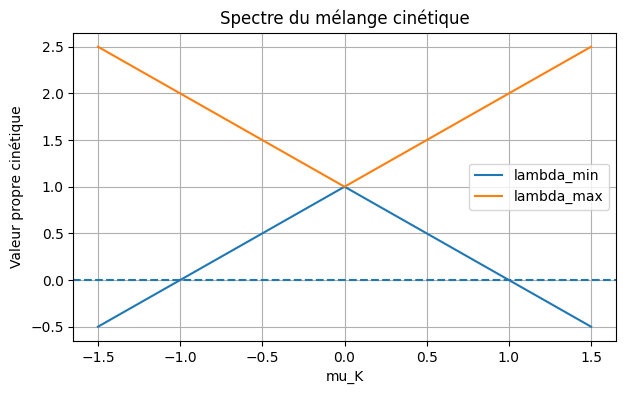

In [11]:

mu_grid = np.linspace(-1.5,1.5,400)
eig_min_grid = []
eig_max_grid = []

for mu in mu_grid:
    eig,_ = kinetic_mix_classification(
        1.0,1.0,mu
    )
    eig_min_grid.append(eig[0])
    eig_max_grid.append(eig[1])

plt.figure(figsize=(7,4))
plt.plot(mu_grid,eig_min_grid,label="lambda_min")
plt.plot(mu_grid,eig_max_grid,label="lambda_max")
plt.axhline(0,linestyle="--")
plt.xlabel("mu_K")
plt.ylabel("Valeur propre cinétique")
plt.title("Spectre du mélange cinétique")
plt.grid(True)
plt.legend()
plt.show()



# 10. Mélange massique

Un mélange de masse peut être écrit :

\[
\mathbf M_{\rm mix}^2
=
\begin{pmatrix}
m_h^2 & \mu_M^2\\
\mu_M^2 & m_D^2
\end{pmatrix}.
\]

Dans le modèle minimal, \(m_h^2=0\).

Un mélange massique direct avec un graviton massless doit être traité avec prudence, car il peut briser la symétrie de jauge gravitationnelle.


In [12]:

m_h2, mu_M2 = sp.symbols(
    "m_h2 mu_M2",
    real=True
)

M_mix_2 = sp.Matrix([
    [m_h2,mu_M2],
    [mu_M2,m_D2]
])

print("Matrice de masse mixte :")
display(M_mix_2)

print("Déterminant :")
display(sp.factor(M_mix_2.det()))

print("Valeurs propres :")
for eig in M_mix_2.eigenvals():
    display(sp.simplify(eig))


Matrice de masse mixte :


⎡mₕ₂   μ_M2⎤
⎢          ⎥
⎣μ_M2  m_D2⎦

Déterminant :


               2
m_D2⋅mₕ₂ - μ_M2 

Valeurs propres :


                _____________________________________
               ╱     2                   2         2 
m_D2   mₕ₂   ╲╱  m_D2  - 2⋅m_D2⋅mₕ₂ + mₕ₂  + 4⋅μ_M2  
──── + ─── - ────────────────────────────────────────
 2      2                       2                    

                _____________________________________
               ╱     2                   2         2 
m_D2   mₕ₂   ╲╱  m_D2  - 2⋅m_D2⋅mₕ₂ + mₕ₂  + 4⋅μ_M2  
──── + ─── + ────────────────────────────────────────
 2      2                       2                    


# 11. Matrices générales des sept modes

Nous autorisons des perturbations diagonales des cinq paramètres directionnels :

\[
K_A,
\qquad
G_A,
\qquad
m_A^2.
\]

Cela permet de tester si une faible rupture de dégénérescence entre les directions crée des instabilités.


In [13]:

K_values = sp.symbols("K1:6", real=True)
G_values = sp.symbols("G1:6", real=True)
M_values = sp.symbols("M1:6", real=True)

K_general = sp.diag(
    K_h,
    K_h,
    *K_values
)

G_general = sp.diag(
    K_h,
    K_h,
    *G_values
)

M_general = sp.diag(
    0,
    0,
    *M_values
)

display(K_general)


⎡Kₕ  0   0   0   0   0   0 ⎤
⎢                          ⎥
⎢0   Kₕ  0   0   0   0   0 ⎥
⎢                          ⎥
⎢0   0   K₁  0   0   0   0 ⎥
⎢                          ⎥
⎢0   0   0   K₂  0   0   0 ⎥
⎢                          ⎥
⎢0   0   0   0   K₃  0   0 ⎥
⎢                          ⎥
⎢0   0   0   0   0   K₄  0 ⎥
⎢                          ⎥
⎣0   0   0   0   0   0   K₅⎦


# 12. Classification automatique d'un spectre

Pour des matrices symétriques \(\mathbf K,\mathbf G,\mathbf M^2\), nous utilisons :

- `GHOST` si \(\lambda_{\min}(\mathbf K)<0\) ;
- `DEGENERATE` si \(\mathbf K\) est singulière ;
- `GRADIENT` si une valeur propre de
  \[
  \mathbf K^{-1/2}\mathbf G\mathbf K^{-1/2}
  \]
  est négative ;
- `SUPERLUMINAL` si une vitesse propre dépasse \(1\) ;
- `TACHYON` si une masse propre est négative ;
- `HEALTHY` sinon.


In [14]:

def symmetric_inverse_sqrt(matrix,tol=1e-12):
    eigvals,eigvecs = np.linalg.eigh(matrix)

    if np.any(eigvals <= tol):
        raise ValueError(
            "La matrice cinétique n'est pas positive définie."
        )

    return (
        eigvecs
        @ np.diag(1/np.sqrt(eigvals))
        @ eigvecs.T
    )

def classify_spectrum(Kmat,Gmat,Mmat,tol=1e-10):
    Kmat = np.asarray(Kmat,dtype=float)
    Gmat = np.asarray(Gmat,dtype=float)
    Mmat = np.asarray(Mmat,dtype=float)

    eigK = np.linalg.eigvalsh(Kmat)

    if eigK.min() < -tol:
        return {
            "status":"GHOST",
            "eigK":eigK
        }

    if eigK.min() <= tol:
        return {
            "status":"DEGENERATE",
            "eigK":eigK
        }

    Kinvhalf = symmetric_inverse_sqrt(Kmat)

    C2 = Kinvhalf@Gmat@Kinvhalf
    Mass2 = Kinvhalf@Mmat@Kinvhalf

    eigC2 = np.linalg.eigvalsh(C2)
    eigM2 = np.linalg.eigvalsh(Mass2)

    if eigC2.min() < -tol:
        status = "GRADIENT"
    elif eigM2.min() < -tol:
        status = "TACHYON"
    elif eigC2.max() > 1+tol:
        status = "SUPERLUMINAL"
    else:
        status = "HEALTHY"

    return {
        "status":status,
        "eigK":eigK,
        "eigC2":eigC2,
        "eigM2":eigM2
    }



# 13. Test du modèle de référence

Nous prenons :

\[
K_h=1,
\quad
K_D=1,
\quad
G_D=0.8,
\quad
m_D^2=0.3.
\]


In [15]:

K_ref = np.eye(7)
G_ref = np.diag(
    [1,1,0.8,0.8,0.8,0.8,0.8]
)
M_ref = np.diag(
    [0,0,0.3,0.3,0.3,0.3,0.3]
)

reference_result = classify_spectrum(
    K_ref,G_ref,M_ref
)

reference_result


{'status': 'HEALTHY',
 'eigK': array([1., 1., 1., 1., 1., 1., 1.]),
 'eigC2': array([0.8, 0.8, 0.8, 0.8, 0.8, 1. , 1. ]),
 'eigM2': array([0. , 0. , 0.3, 0.3, 0.3, 0.3, 0.3])}


# 14. Scan des paramètres directionnels

Nous explorons :

\[
K_D,
\qquad
G_D,
\qquad
m_D^2.
\]


In [16]:

scan_rows = []

for KD in [-1.0,0.0,0.5,1.0,2.0]:
    for GD in [-0.5,0.2,0.8,1.5]:
        for MD in [-0.5,0.0,0.3,1.0]:
            Kmat = np.diag(
                [1,1]+[KD]*5
            )
            Gmat = np.diag(
                [1,1]+[GD]*5
            )
            Mmat = np.diag(
                [0,0]+[MD]*5
            )

            result = classify_spectrum(
                Kmat,Gmat,Mmat
            )

            scan_rows.append({
                "K_D":KD,
                "G_D":GD,
                "m_D2":MD,
                "status":result["status"]
            })

scan_df = pd.DataFrame(scan_rows)
scan_df.head(20)


,K_D,G_D,m_D2,status
0,-1.0,-0.5,-0.5,GHOST
1,-1.0,-0.5,0.0,GHOST
2,-1.0,-0.5,0.3,GHOST
3,-1.0,-0.5,1.0,GHOST
4,-1.0,0.2,-0.5,GHOST
5,-1.0,0.2,0.0,GHOST
6,-1.0,0.2,0.3,GHOST
7,-1.0,0.2,1.0,GHOST
8,-1.0,0.8,-0.5,GHOST
9,-1.0,0.8,0.0,GHOST



# 15. Carte de stabilité dans le plan \((G_D,m_D^2)\)

Pour \(K_D=1\), nous classons chaque point.


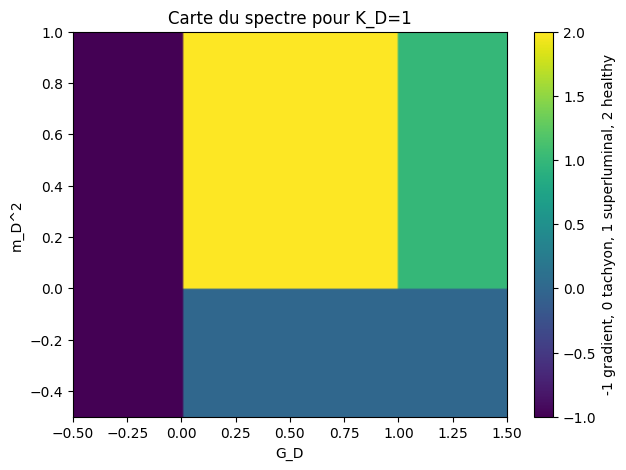

In [17]:

G_grid = np.linspace(-0.5,1.5,150)
M_grid = np.linspace(-0.5,1.0,150)

status_code = {
    "GHOST":-3,
    "DEGENERATE":-2,
    "GRADIENT":-1,
    "TACHYON":0,
    "SUPERLUMINAL":1,
    "HEALTHY":2
}

stability_map = np.zeros(
    (len(M_grid),len(G_grid))
)

for i,MD in enumerate(M_grid):
    for j,GD in enumerate(G_grid):
        result = classify_spectrum(
            np.eye(7),
            np.diag([1,1]+[GD]*5),
            np.diag([0,0]+[MD]*5)
        )
        stability_map[i,j] = status_code[
            result["status"]
        ]

plt.figure(figsize=(7,5))
plt.imshow(
    stability_map,
    origin="lower",
    extent=[
        G_grid.min(),
        G_grid.max(),
        M_grid.min(),
        M_grid.max()
    ],
    aspect="auto"
)
plt.xlabel("G_D")
plt.ylabel("m_D^2")
plt.title("Carte du spectre pour K_D=1")
plt.colorbar(
    label="-1 gradient, 0 tachyon, 1 superluminal, 2 healthy"
)
plt.show()



# 16. Courbes de dispersion

Pour plusieurs nombres d'onde :

\[
\omega_D(k)
=
\sqrt{
c_D^2k^2+m_{\rm eff}^2
}.
\]


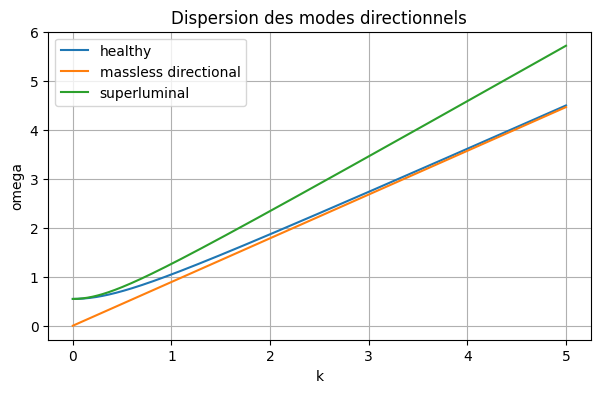

In [18]:

k_values = np.linspace(0,5,400)

dispersion_cases = [
    {
        "label":"healthy",
        "KD":1.0,
        "GD":0.8,
        "M2":0.3
    },
    {
        "label":"massless directional",
        "KD":1.0,
        "GD":0.8,
        "M2":0.0
    },
    {
        "label":"superluminal",
        "KD":1.0,
        "GD":1.3,
        "M2":0.3
    }
]

plt.figure(figsize=(7,4))

for case in dispersion_cases:
    omega2_values = (
        case["GD"]/case["KD"]*k_values**2
        + case["M2"]/case["KD"]
    )
    omega_values = np.sqrt(
        np.maximum(omega2_values,0)
    )
    plt.plot(
        k_values,
        omega_values,
        label=case["label"]
    )

plt.xlabel("k")
plt.ylabel("omega")
plt.title("Dispersion des modes directionnels")
plt.grid(True)
plt.legend()
plt.show()



# 17. Vitesse de groupe

La vitesse de groupe est :

\[
v_g
=
\frac{\partial\omega}{\partial k}
=
\frac{c_D^2k}
{\sqrt{c_D^2k^2+m_{\rm eff}^2}}.
\]

À grand \(k\) :

\[
v_g\rightarrow c_D.
\]


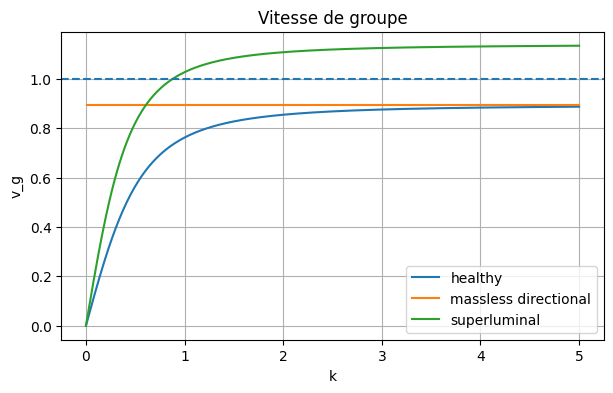

In [19]:

def group_velocity(kv,KD,GD,M2):
    c2 = GD/KD
    omega2 = c2*kv**2+M2/KD

    result = np.full_like(
        kv,
        np.nan,
        dtype=float
    )

    mask = omega2 > 0

    result[mask] = (
        c2*kv[mask]
        / np.sqrt(omega2[mask])
    )

    return result

plt.figure(figsize=(7,4))

for case in dispersion_cases:
    vg = group_velocity(
        k_values,
        case["KD"],
        case["GD"],
        case["M2"]
    )
    plt.plot(
        k_values,
        vg,
        label=case["label"]
    )

plt.axhline(1,linestyle="--")
plt.xlabel("k")
plt.ylabel("v_g")
plt.title("Vitesse de groupe")
plt.grid(True)
plt.legend()
plt.show()



# 18. Sensibilité aux cinq modes non dégénérés

Nous générons des perturbations aléatoires autour du modèle de référence :

\[
K_A=1+\delta K_A,
\]

\[
G_A=0.8+\delta G_A,
\]

\[
m_A^2=0.3+\delta m_A^2.
\]

L'objectif est de vérifier si la région saine possède une largeur non nulle.


In [20]:

rng = np.random.default_rng(2026)

monte_carlo_rows = []

for sample in range(2000):
    Kdir = 1.0+rng.normal(
        scale=0.12,
        size=5
    )
    Gdir = 0.8+rng.normal(
        scale=0.12,
        size=5
    )
    Mdir = 0.3+rng.normal(
        scale=0.10,
        size=5
    )

    Kmat = np.diag(
        np.concatenate([
            [1,1],
            Kdir
        ])
    )

    Gmat = np.diag(
        np.concatenate([
            [1,1],
            Gdir
        ])
    )

    Mmat = np.diag(
        np.concatenate([
            [0,0],
            Mdir
        ])
    )

    result = classify_spectrum(
        Kmat,Gmat,Mmat
    )

    monte_carlo_rows.append({
        "sample":sample,
        "status":result["status"],
        "min_K":np.min(Kdir),
        "max_c2":np.max(Gdir/Kdir),
        "min_m2":np.min(Mdir/Kdir)
    })

monte_carlo_df = pd.DataFrame(
    monte_carlo_rows
)

monte_carlo_df["status"].value_counts()


,count
status,
HEALTHY,1027
SUPERLUMINAL,961
TACHYON,12



# 19. Action quadratique avec mélange complet candidat

Nous construisons une matrice cinétique test :

\[
\mathbf K
=
\mathbf K_0
+
\epsilon_K\mathbf C,
\]

où \(\mathbf C\) est symétrique.

L'objectif n'est pas de choisir un couplage physique, mais de mesurer la robustesse du spectre face à des mélanges faibles.


In [21]:

rng = np.random.default_rng(17)

C_random = rng.normal(
    size=(7,7)
)
C_random = (
    C_random+C_random.T
)/2

epsilon_values = np.linspace(
    0,
    0.8,
    100
)

mixing_rows = []

for eps in epsilon_values:
    Ktest = K_ref+eps*C_random

    eigK = np.linalg.eigvalsh(
        Ktest
    )

    mixing_rows.append({
        "epsilon":eps,
        "min_eig_K":eigK.min(),
        "max_eig_K":eigK.max(),
        "positive_definite":bool(
            eigK.min()>0
        )
    })

mixing_scan_df = pd.DataFrame(
    mixing_rows
)

mixing_scan_df.head()


,epsilon,min_eig_K,max_eig_K,positive_definite
0,0.000000,1.000000,1.000000,True
1,0.008081,0.976625,1.030953,True
2,0.016162,0.953249,1.061906,True
3,0.024242,0.929874,1.092859,True
4,0.032323,0.906498,1.123812,True


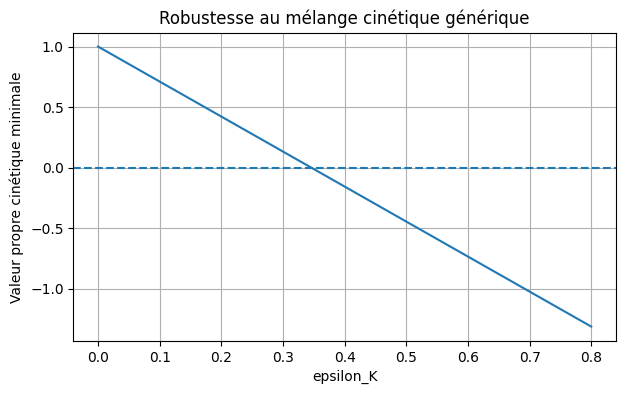

In [22]:

plt.figure(figsize=(7,4))
plt.plot(
    mixing_scan_df["epsilon"],
    mixing_scan_df["min_eig_K"]
)
plt.axhline(0,linestyle="--")
plt.xlabel("epsilon_K")
plt.ylabel("Valeur propre cinétique minimale")
plt.title("Robustesse au mélange cinétique générique")
plt.grid(True)
plt.show()



# 20. Séparation des diagnostics

Il est essentiel de ne pas confondre :

- **ghost** :
  valeur propre cinétique négative ;

- **tachyon** :
  masse effective au carré négative ;

- **instabilité de gradient** :
  vitesse propre au carré négative ;

- **superluminalité effective** :
  vitesse propre supérieure à \(1\) ;

- **dégénérescence** :
  valeur propre cinétique nulle ;

- **fort couplage** :
  coefficient cinétique très petit.


In [23]:

diagnostic_dictionary = pd.DataFrame([
    {
        "diagnostic":"ghost",
        "criterion":"negative kinetic eigenvalue"
    },
    {
        "diagnostic":"tachyon",
        "criterion":"negative effective mass squared"
    },
    {
        "diagnostic":"gradient instability",
        "criterion":"negative propagation-speed eigenvalue"
    },
    {
        "diagnostic":"superluminality",
        "criterion":"speed-squared eigenvalue > 1"
    },
    {
        "diagnostic":"degeneracy",
        "criterion":"zero kinetic eigenvalue"
    },
    {
        "diagnostic":"strong coupling",
        "criterion":"very small positive kinetic eigenvalue"
    }
])

diagnostic_dictionary


,diagnostic,criterion
0,ghost,negative kinetic eigenvalue
1,tachyon,negative effective mass squared
2,gradient instability,negative propagation-speed eigenvalue
3,superluminality,speed-squared eigenvalue > 1
4,degeneracy,zero kinetic eigenvalue
5,strong coupling,very small positive kinetic eigenvalue



# 21. Limite d'Einstein

Lorsque les cinq modes directionnels sont désactivés :

\[
q_A=0,
\]

il reste :

\[
S_{\rm GR}^{(2)}
=
\frac12
\int d^4x
K_h
\left[
\dot h_+^2
-
(\nabla h_+)^2
+
\dot h_\times^2
-
(\nabla h_\times)^2
\right].
\]

Le spectre revient aux deux gravitons massless.


In [24]:

einstein_limit_spectrum = pd.DataFrame([
    {
        "mode":"h_plus",
        "mass_squared":0,
        "speed_squared":1,
        "kinetic_sign":"positive if K_h>0"
    },
    {
        "mode":"h_cross",
        "mass_squared":0,
        "speed_squared":1,
        "kinetic_sign":"positive if K_h>0"
    }
])

einstein_limit_spectrum


,mode,mass_squared,speed_squared,kinetic_sign
0,h_plus,0,1,positive if K_h>0
1,h_cross,0,1,positive if K_h>0



# 22. Validation automatique

Nous validons :

1. sept modes dans les matrices ;
2. cinq modes directionnels dégénérés dans le modèle minimal ;
3. déterminant factorisé attendu ;
4. modèle de référence classé `HEALTHY` ;
5. seuil de mélange cinétique correctement détecté ;
6. limite d'Einstein à deux modes massless.


In [25]:

matrix_size_ok = (
    K_matrix.shape == (7,7)
    and G_matrix.shape == (7,7)
    and M2_matrix.shape == (7,7)
)

directional_degeneracy_ok = (
    kinetic_eigenvalues.count(K_D) == 5
)

expected_det = sp.factor(
    (
        K_h*(omega**2-k**2)
    )**2
    * (
        K_D*omega**2
        - G_D*k**2
        - m_D2
    )**5
)

determinant_ok = (
    sp.simplify(
        operator_determinant-expected_det
    ) == 0
)

reference_healthy_ok = (
    reference_result["status"]=="HEALTHY"
)

mix_below = kinetic_mix_classification(
    1,1,0.5
)[1]

mix_above = kinetic_mix_classification(
    1,1,1.2
)[1]

mix_threshold_ok = (
    mix_below=="HEALTHY"
    and mix_above=="GHOST"
)

einstein_limit_ok = (
    len(einstein_limit_spectrum)==2
    and (
        einstein_limit_spectrum["mass_squared"]==0
    ).all()
)

validation_df = pd.DataFrame([
    {
        "test":"seven-mode matrices",
        "status":"PASS" if matrix_size_ok else "FAIL"
    },
    {
        "test":"five directional kinetic modes",
        "status":"PASS" if directional_degeneracy_ok else "FAIL"
    },
    {
        "test":"operator determinant factorization",
        "status":"PASS" if determinant_ok else "FAIL"
    },
    {
        "test":"healthy reference spectrum",
        "status":"PASS" if reference_healthy_ok else "FAIL"
    },
    {
        "test":"kinetic mixing threshold",
        "status":"PASS" if mix_threshold_ok else "FAIL"
    },
    {
        "test":"Einstein two-mode limit",
        "status":"PASS" if einstein_limit_ok else "FAIL"
    }
])

validation_df


,test,status
0,seven-mode matrices,PASS
1,five directional kinetic modes,PASS
2,operator determinant factorization,PASS
3,healthy reference spectrum,PASS
4,kinetic mixing threshold,PASS
5,Einstein two-mode limit,PASS


In [26]:

overall_status = (
    "HEALTHY-MINIMAL"
    if (
        validation_df["status"]=="PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU SPECTRE MINIMAL :",overall_status)
print("STATUT DU TENSEUR COVARIANT COMPLET : CHECK")


STATUT DU SPECTRE MINIMAL : HEALTHY-MINIMAL
STATUT DU TENSEUR COVARIANT COMPLET : CHECK



# 23. Export


In [27]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.18_Validation.csv",
    index=False
)

kinetic_spectrum.to_csv(
    "GVH_Diagonal_Cubic_0.2.18_Kinetic_Spectrum.csv",
    index=False
)

scan_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.18_Parameter_Scan.csv",
    index=False
)

mix_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.18_Kinetic_Mixing.csv",
    index=False
)

monte_carlo_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.18_Mode_Sensitivity.csv",
    index=False
)

mixing_scan_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.18_Generic_Mixing_Robustness.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "model":"minimal quadratic seven-mode action",
    "metric_modes":2,
    "directional_modes":5,
    "healthy_conditions":{
        "K_h":"> 0",
        "K_D":"> 0",
        "G_D":">= 0",
        "G_D_over_K_D":"between 0 and 1",
        "m_D_squared":">= 0"
    },
    "directional_dispersion":"omega^2=(G_D k^2+m_D^2)/K_D",
    "kinetic_mixing_bound":"mu_K^2 < K_h K_D",
    "Einstein_limit":"two massless tensor modes",
    "full_covariant_tensor_status":"not yet proven"
}

with open(
    "GVH_Diagonal_Cubic_0.2.18_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 24. Conclusion scientifique

Pour l'action quadratique minimale :

\[
\boxed{
S^{(2)}
=
S_{\rm GR}^{(2)}
+
\frac12
\int d^4x
\sum_{A=1}^{5}
\left[
K_D\dot q_A^2
-
G_D(\nabla q_A)^2
-
m_D^2q_A^2
\right]
}
\]

le spectre contient :

\[
\boxed{
2\text{ gravitons massless}
+
5\text{ modes directionnels}
}.
\]

Le secteur minimal est sain si :

\[
\boxed{
K_D>0,
\qquad
0\le\frac{G_D}{K_D}\le1,
\qquad
m_D^2\ge0
}.
\]

Un mélange cinétique simple reste sain seulement si :

\[
\boxed{
\mu_K^2<K_hK_D
}.
\]

Le résultat correct est :

\[
\boxed{
\text{absence de ghost démontrée pour l'action quadratique minimale}
}
\]

mais :

\[
\boxed{
\text{absence de ghost du tenseur covariant complet :
encore à démontrer}
}.
\]

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.19\_Linearized\_Field\_Equations\_Wave\_Polarizations.ipynb}
}
\]

Elle devra étudier :

- les équations linéarisées ;
- les sept polarisations ;
- la réponse d'un détecteur ;
- les vitesses de propagation ;
- les modes massifs ou massless ;
- la limite des ondes gravitationnelles de la relativité générale ;
- les signatures observationnelles potentielles.
